# Fixed-spread baseline

I use fixed seeds here so the numerical examples remain comparable when the implementation changes.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT/"src"))
pd.set_option("display.max_columns", 30)

I use fixed quoting as the reference case because it exposes the basic trade-off between earning more per fill and receiving fewer fills.

In [2]:
from market_maker_lab.analysis import expected_spread_rate, optimal_half_spread
h=np.linspace(.005,.15,120)
r=np.array([expected_spread_rate(x,90,18) for x in h])
print("Analytical gross-revenue optimum:",optimal_half_spread(18))
print("Grid optimum:",h[r.argmax()])

Analytical gross-revenue optimum: 0.05555555555555555
Grid optimum: 0.054957983193277306


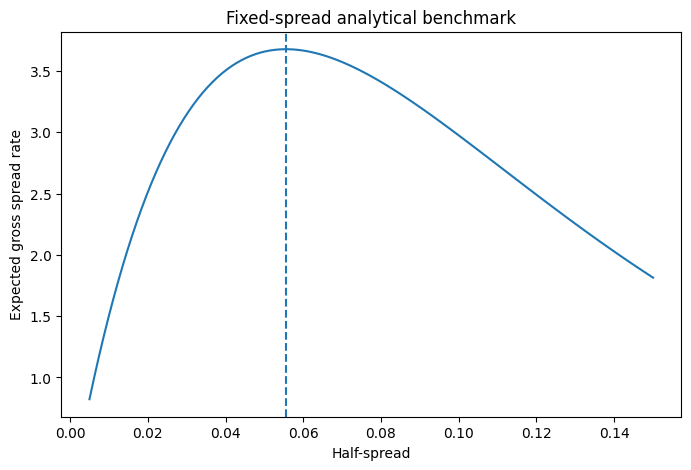

In [3]:
plt.figure(figsize=(8,5)); plt.plot(h,r); plt.axvline(optimal_half_spread(18),linestyle="--"); plt.xlabel("Half-spread"); plt.ylabel("Expected gross spread rate"); plt.title("Fixed-spread analytical benchmark"); plt.show()

In [4]:
summary=pd.read_csv(ROOT/"outputs/tables/strategy_summary.csv")
summary[summary.strategy=="fixed"][["scenario","mean_terminal_pnl","pnl_5_percentile","mean_absolute_inventory","mean_traded_quantity"]]

,scenario,mean_terminal_pnl,pnl_5_percentile,mean_absolute_inventory,mean_traded_quantity
0,clean,3.412374,-5.770058,4.6467,67.100
5,high_volatility,3.083607,-21.220302,4.7217,66.775
10,one_sided,2.589933,-33.072656,20.8755,76.200
15,regime_switching,0.012943,-20.214144,5.0596,82.750
20,stress,-62.118215,-284.973340,29.0320,124.675
25,toxic,-2.863340,-21.858940,6.4028,100.700
